# День 7. Регрессия и спектральный анализ (FFT)

**Курс:** ДПК «Практические навыки и опыт анализа данных с помощью Python»  
**Источник данных:** карьер «Восточный» (золотодобыча) — реальная производственная телеметрия и геомеханика.

> 💡 Заполняйте ячейки `# TODO`. Подсказки даны в комментариях. Не стесняйтесь спрашивать преподавателя.


## Импорт библиотек

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Базовые настройки
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

DATA_DIR = r'C:\Users\Adil\Downloads\ДПК_ВД-25\datasets'  # путь к папке с датасетами


## Задание 7.1. «Прогноз скорости проходки» — линейная регрессия


In [ ]:
gold =...



(5000, 18)


In [8]:
gold.columns

Index(['Id_Drill_Trans', 'Drill_Start_Timestamp', 'End_Timestamp', 'X', 'Y', 'Z', 'Depth', 'Pit_Name', 'Drill_Passport', 'Hole_Code', 'Cycle_Shift_Date',
       'Short_Name', 'Litology_Code', 'SEGMENT_DEPTH', 'WEIGHT_ON_BIT', 'ROTATION_PER_MINUTE', 'TORQUE', 'RATE_OF_PENETRATION'],
      dtype='object')

### Простая регрессия: ROP ~ UCS

Используем `sklearn.linear_model.LinearRegression`. Альтернативно можно `statsmodels.api.OLS` (даёт более подробный отчёт со значениями t-статистик и p-value).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

ucs_col = 'ucs_mpa_mean' if 'ucs_mpa_mean' in gold.columns else 'UCS'

# Берём только полные строки
data = ...
print('Размер обучающей выборки:', len(data))

X = data[].values
y = data[].values

model_simple =...
y_pred_simple =...
r2_simple = ...

print(f'Уравнение: ROP = {model_simple.intercept_:.2f} + ({model_simple.coef_[0]:.4f}) * UCS')
print(f'R² = {r2_simple:.3f}')


KeyError: "['UCS'] not in index"

**Интерпретация:**
- Коэффициент при UCS — на сколько (м/ч) меняется ROP при росте UCS на 1 МПа.
- R² — доля вариации ROP, объяснённая моделью.

Если R² близок к нулю — модель плохая, признак не объясняет ROP.

### Расширенный отчёт через statsmodels (если установлен)

Если `statsmodels` доступен, он покажет t-статистики и p-value для каждого коэффициента — полезно для проверки значимости признака.

In [ ]:

import statsmodels.api as sm
X_sm = ...
model_sm =...
print(model_sm.summary())


### Множественная регрессия: ROP ~ UCS + WOB + RPM

In [ ]:
feats = [ucs_col]
if 'WEIGHT_ON_BIT' in gold.columns: feats.append('WEIGHT_ON_BIT')
if 'ROTATION_PER_MINUTE' in gold.columns: feats.append('ROTATION_PER_MINUTE')

data_m =...
X_m = data_m[].values
y_m = data_m[].values

model_multi = ...
y_pred_multi =...
r2_multi = ...

print('Коэффициенты:')
for f, c in zip(feats, model_multi.coef_):
    print(f'  {f}: {c:+.4f}')
print(f'  intercept: {model_multi.intercept_:.2f}')
print(f'R² = {r2_multi:.3f}')


In [ ]:
print(f'R² простой модели:        {r2_simple:.3f}')
print(f'R² множественной модели:  {r2_multi:.3f}')
print(f'Прирост:                  {r2_multi - r2_simple:+.3f}')


### Scatter «факт vs прогноз»

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(...)
lims = ...
ax.plot(..., 'r--', label='y = x (идеальный прогноз)')
ax.set_xlabel('Факт ROP, м/ч')
ax.set_ylabel('Прогноз ROP, м/ч')
ax.set_title(f'Множественная регрессия ROP — R² = {r2_multi:.3f}')
ax.legend()
plt.tight_layout()
plt.show()


---
## Задание 7.2. «Анализ виброграммы массового взрыва» (FFT)

**Данные:** `vibration.csv` — синтетический сигнал сейсмоприёмника (fs = 1000 Гц, 8 с).


In [3]:
vib = pd.read_csv(f'{DATA_DIR}/vibration.csv')
print(vib.shape)
vib.head()


(8000, 2)


,time_s,acceleration_m_s2
0,0.000,0.003725
1,0.001,0.032208
2,0.002,0.063481
3,0.003,0.083745
4,0.004,0.074659


### Шаг 1. Визуализация сигнала во временной области

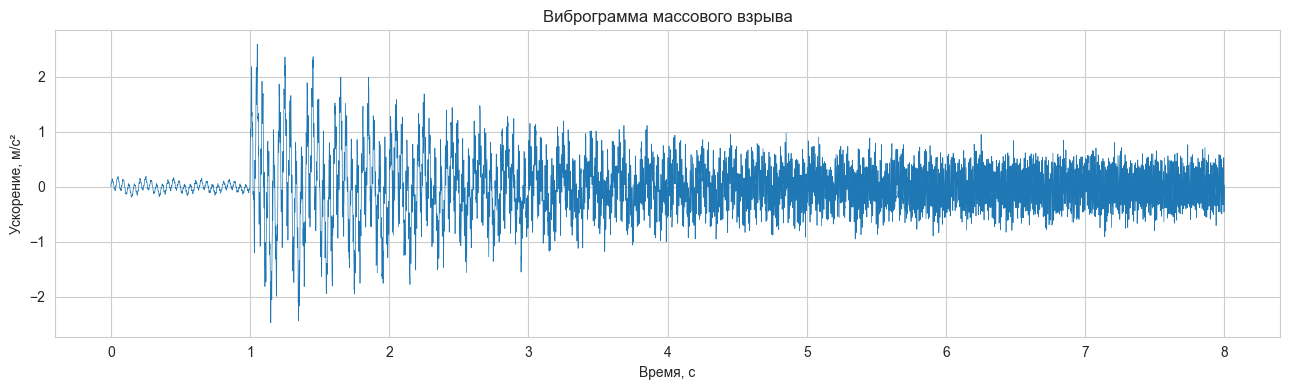

In [ ]:
fs = 1000  # частота дискретизации, Гц
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(...)
ax.set_xlabel('Время, с')
ax.set_ylabel('Ускорение, м/с²')
ax.set_title('Виброграмма массового взрыва')
plt.tight_layout()
plt.show()


### Шаг 2. FFT

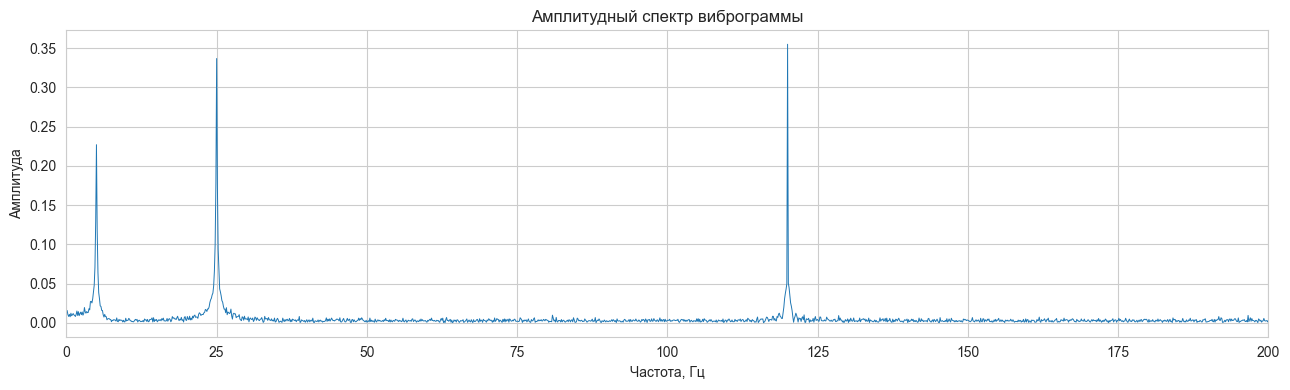

In [8]:
signal = vib['acceleration_m_s2'].values
N = len(signal)

# TODO: применить FFT

spectrum = np.fft.fft(signal)
amp = np.abs(spectrum) / N * 2  # нормировка на длину, умножаем на 2 (одностороннее)
freqs = np.fft.fftfreq(N, d=1/fs)

# Берём только положительные частоты
pos = freqs > 0
freqs_pos = freqs[pos]
amp_pos = amp[pos]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(freqs_pos, amp_pos, lw=0.7)
ax.set_xlabel('Частота, Гц')
ax.set_ylabel('Амплитуда')
ax.set_title('Амплитудный спектр виброграммы')
ax.set_xlim(0, 200)
plt.tight_layout()
plt.show()


### Шаг 3. Поиск доминирующих частот

In [9]:
from scipy.signal import find_peaks

# TODO: найти пики амплитудного спектра
peaks, _ = find_peaks(amp_pos, height=amp_pos.max() * 0.1, distance=20)
top_peaks = sorted(peaks, key=lambda i: -amp_pos[i])[:5]

for p in top_peaks:
    print(f'  f = {freqs_pos[p]:7.2f} Гц,  амплитуда = {amp_pos[p]:.4f}')


  f =  120.00 Гц,  амплитуда = 0.3548
  f =   25.00 Гц,  амплитуда = 0.3366
  f =    5.00 Гц,  амплитуда = 0.2269


### Шаг 4. Фильтр нижних частот (50 Гц)

Зануляем компоненты спектра с частотой выше 50 Гц и делаем обратное FFT.

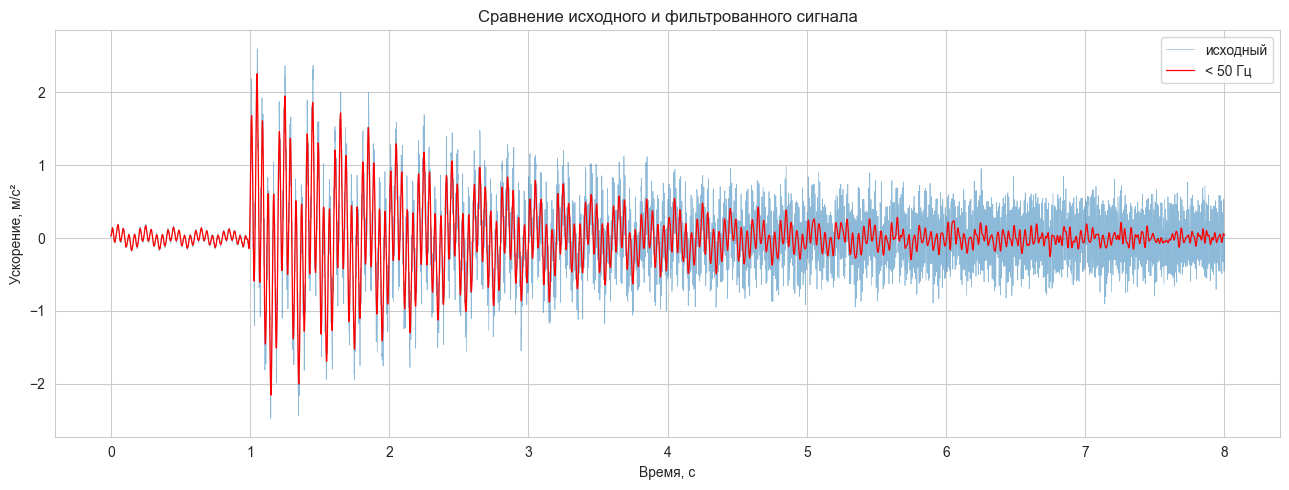

In [10]:
CUTOFF = 50.0  # Гц
spectrum_filt = spectrum.copy()
spectrum_filt[np.abs(freqs) > CUTOFF] = 0
signal_filt = np.real(np.fft.ifft(spectrum_filt))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(vib['time_s'], signal, lw=0.5, alpha=0.5, label='исходный')
ax.plot(vib['time_s'], signal_filt, lw=0.9, color='red', label='< 50 Гц')
ax.set_xlabel('Время, с')
ax.set_ylabel('Ускорение, м/с²')
ax.set_title('Сравнение исходного и фильтрованного сигнала')
ax.legend()
plt.tight_layout()
plt.show()


---
## Задание 7.3. «Спектр TORQUE по глубине скважины»

**Данные:** `drilling_signal_one_hole.csv` — TORQUE/WOB/RPM/ROP вдоль глубины одной скважины.


In [11]:
sig = pd.read_csv(f'{DATA_DIR}/drilling_signal_one_hole.csv').sort_values('depth_m')
print(sig.shape)
sig.head()


(5910, 5)


,depth_m,torque,weight_on_bit,rotation_rpm,rop_m_h
0,-19.19,0.32,-36.28,2,954.0
1,-3.66,0.81,-13.02,0,96.0
2,-2.07,3.22,4.50,51,417.6
3,-2.04,1.33,-14.54,15,114.0
4,-2.00,5.10,-17.88,95,136.8


### Шаг 1. Интерполяция на равномерную сетку глубин

FFT требует, чтобы выборка была равномерной по аргументу (здесь — по глубине).

In [12]:
depth = sig['depth_m'].values
torque = sig['torque'].values

# Равномерная сетка
depth_uniform = np.linspace(depth.min(), depth.max(), len(depth))
step = depth_uniform[1] - depth_uniform[0]
torque_uniform = np.interp(depth_uniform, depth, torque)
print(f'Шаг по глубине: {step*1000:.2f} мм')


Шаг по глубине: 3.43 мм


### Шаг 2. FFT и спектр в координатах «период, м»

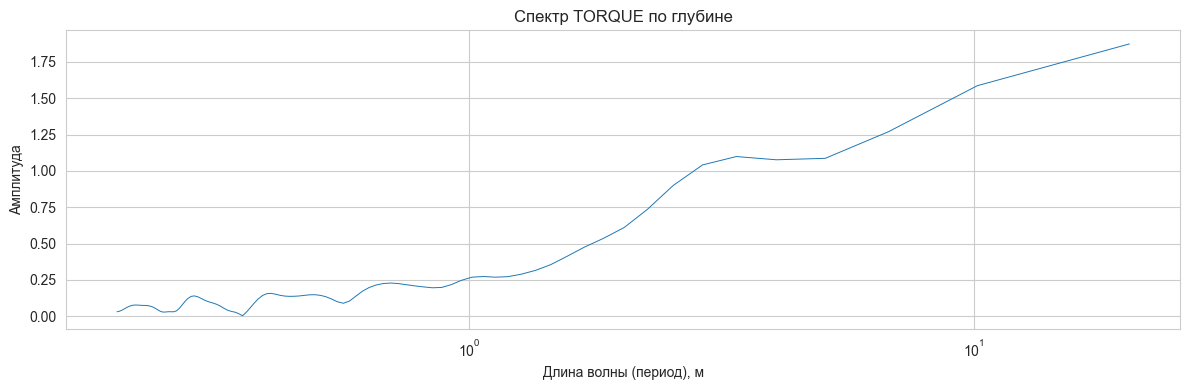

In [13]:
N = len(torque_uniform)
# Спектральная частота — это [1/м]
spec = np.fft.fft(torque_uniform - torque_uniform.mean())  # убираем DC-составляющую
amp = np.abs(spec) / N * 2
k = np.fft.fftfreq(N, d=step)  # пространственная частота

pos = (k > 0) & (k < 5)  # период от 0.2 до бесконечности м
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(1/k[pos], amp[pos], lw=0.7)  # ось X — длина волны (м)
ax.set_xlabel('Длина волны (период), м')
ax.set_ylabel('Амплитуда')
ax.set_xscale('log')
ax.set_title('Спектр TORQUE по глубине')
plt.tight_layout()
plt.show()


### Шаг 3. Сглаживание Савицкого-Голея для сравнения с FFT-фильтром

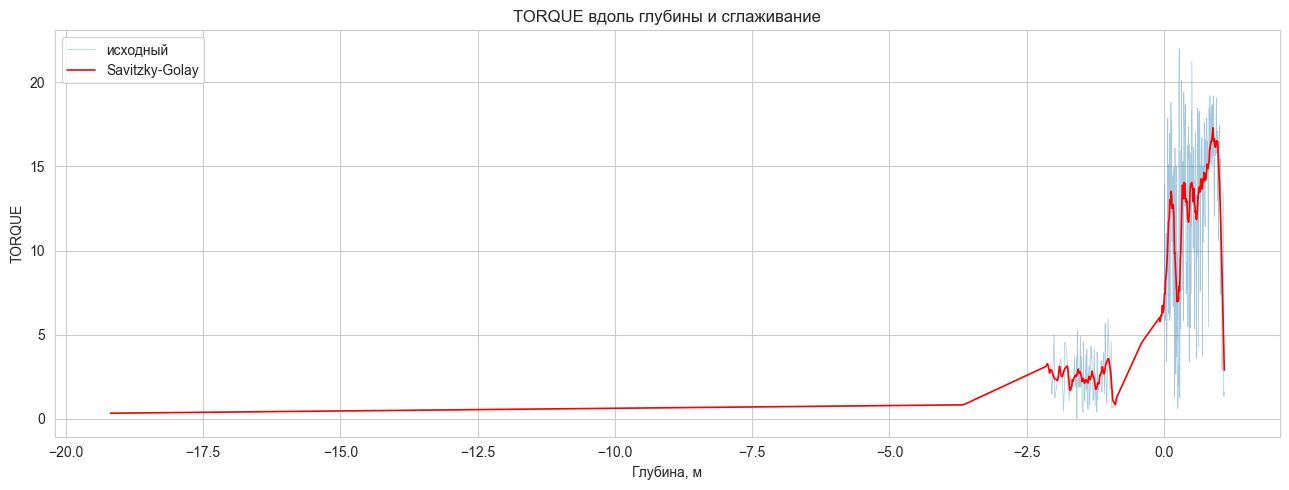

In [14]:
from scipy.signal import savgol_filter

torque_smooth = savgol_filter(torque_uniform, window_length=51, polyorder=3)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(depth_uniform, torque_uniform, alpha=0.4, lw=0.5, label='исходный')
ax.plot(depth_uniform, torque_smooth, color='red', lw=1.2, label='Savitzky-Golay')
ax.set_xlabel('Глубина, м')
ax.set_ylabel('TORQUE')
ax.set_title('TORQUE вдоль глубины и сглаживание')
ax.legend()
plt.tight_layout()
plt.show()


**Вывод (заполните):**  
Какие характерные периоды (длины волны) проявляются в спектре? Соответствует ли это мощности литологических слоёв?